In [28]:
class Value:
    def __init__(self,data,_children=(),_op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op=_op
        self.label= label

    def __repr__(self):
        return f"Value(data={self.data})" 

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
            out = Value(self.data * other.data, (self, other),"*")
            return out

#Initial forward pass
a=Value(2.0, label='a')
b=Value(-3.0, label='b')
c=Value(10.0, label='c')
e= a*b; e.label = 'e'
d= e + c; d.label = 'd' 
f = Value(-2.0, label='f')
L = d * f; L.label='L'




Value(data=4.0)

In [26]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

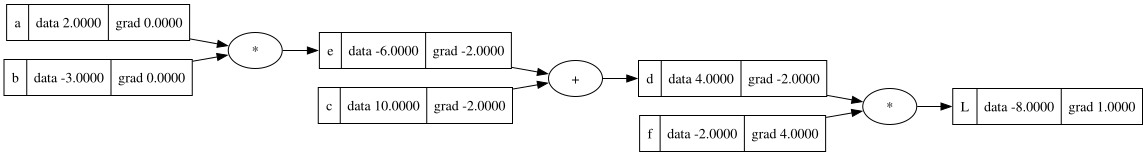

In [58]:
draw_dot(L)

In [45]:
#dL/dL
def Manuel_Gradient_Fillin():
    h= 0.001 #our little bumper
    
    #Initial forward pass
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

   
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data + h

    print("dl/dl= ",(L2-L1)/h)
Manuel_Gradient_Fillin()

dl/dl=  1.000000000000334


In [46]:
L.grad= 1.0

In [47]:
#dL/dd
def Manuel_Gradient_Fillin():
    h= 0.001 #our little bumper
    
    #Initial forward pass
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

   
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    d.data +=h
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data 

    print("dl/dd= ",(L2-L1)/h)
Manuel_Gradient_Fillin()

dl/dd=  -2.000000000000668


In [48]:
d.grad= -2.0

In [49]:
#dL/df
def Manuel_Gradient_Fillin():
    h= 0.001 #our little bumper
    
    #Initial forward pass
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

   
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    f.data +=h
    L = d * f; L.label='L'
    L2 = L.data 

    print("dl/df= ",(L2-L1)/h)
Manuel_Gradient_Fillin()

dl/df=  3.9999999999995595


In [50]:
f.grad= 4.0

In [52]:
#dL/de
def Manuel_Gradient_Fillin():
    h= 0.001 #our little bumper
    
    #Initial forward pass
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

   
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    e.data +=h
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data 

    print("dl/de= ",(L2-L1)/h)
Manuel_Gradient_Fillin()

dl/de=  -2.000000000000668


In [53]:
e.grad= -2.0

In [55]:
#dL/dc
def Manuel_Gradient_Fillin():
    h= 0.001 #our little bumper
    
    #Initial forward pass
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

   
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    c.data +=h
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data 

    print("dl/dc= ",(L2-L1)/h)
Manuel_Gradient_Fillin()

dl/dc=  -1.9999999999988916


In [56]:
c.grad=-2

In [57]:
#dL/db
def Manuel_Gradient_Fillin():
    h= 0.001 #our little bumper
    
    #Initial forward pass
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

   
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    b.data +=h
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data 

    print("dl/db= ",(L2-L1)/h)
Manuel_Gradient_Fillin()

dl/db=  -3.9999999999995595


In [59]:
b.grad= -4.0

In [60]:
#dL/da
def Manuel_Gradient_Fillin():
    h= 0.001 #our little bumper
    
    #Initial forward pass
    a=Value(2.0, label='a')
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

   
    a=Value(2.0, label='a')
    a.data +=h
    b=Value(-3.0, label='b')
    c=Value(10.0, label='c')
    e= a*b; e.label = 'e'
    d= e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data 

    print("dl/da= ",(L2-L1)/h)
Manuel_Gradient_Fillin()

dl/da=  6.000000000000227


In [61]:
a.grad=6.0

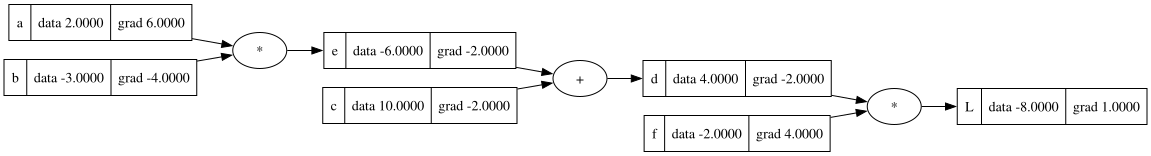

In [63]:
draw_dot(L)

In [73]:
#tanh added to class
import math

class Value:
    def __init__(self,data,_children=(),_op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op=_op
        self.label= label

    def __repr__(self):
        return f"Value(data={self.data})" 

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
            out = Value(self.data * other.data, (self, other),"*")
            return out

    def tanh(self):
        x=self.data
        t = (math.exp(2*x) - 1) / (math.exp (2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out

In [85]:
#For neuron manuel filling
#inputs & parameters
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.881373, label='b')
#weighted sums

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2= x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

n= x1w1x2w2 + b; n.label= 'n'
o=n.tanh(); o.label= 'o'

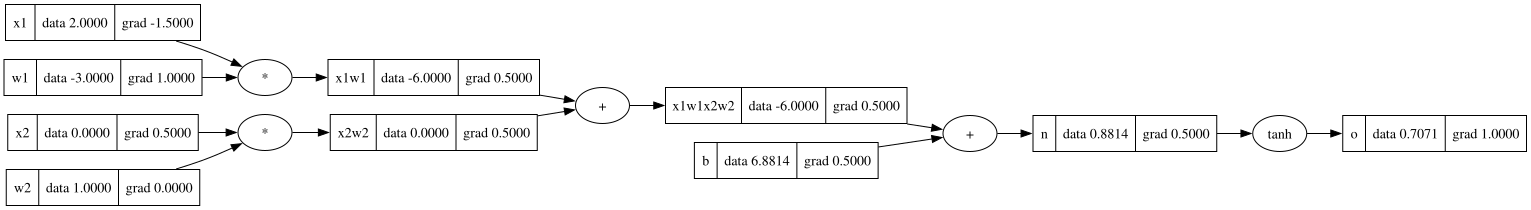

In [105]:
draw_dot(o)

In [86]:
o.grad= 1.0

In [97]:
# o = tanh(n)
# do/dn = 1 - tanh^2(n) -> do/dn = 1 - o^2 -> do/dn = 1- o.data^2

In [93]:
n.grad = 1-o.data**2

In [106]:
# after that there is plus operator that means we should just let the gradient flow so 

In [99]:
x1w1x2w2.grad=0.5
b.grad=0.5

In [100]:
#again plus operator

In [101]:
x1w1.grad=0.5
x2w2.grad=0.5

In [103]:
#for upper section x1.grad= local derrivative * x1w1.grad -> w1 * 0.5 -> -1.5 & w1.grad = x1w1.grad * x1-> 1
#same goes on bottom section 

In [104]:
x1.grad= -1.5
w1.grad= 1.0
x2.grad =0.5
w2.grad = 0

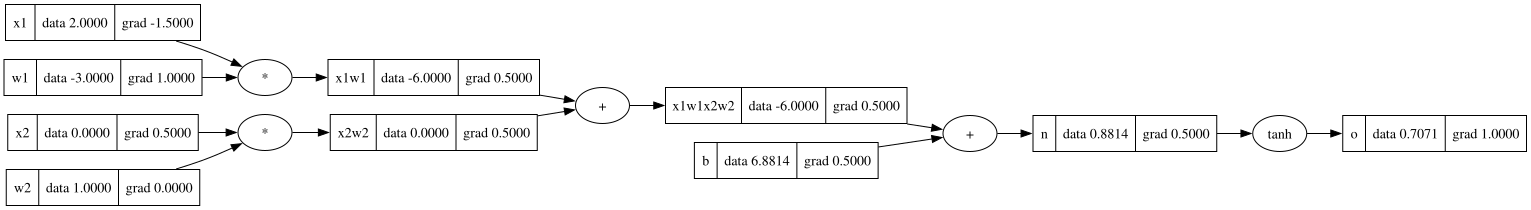

In [107]:
draw_dot(o)